<a target="_blank" href="https://github.com/aldebaro/ml-ufpa/tree/main/nb_dos_caras_safos/Decision_tree/ml_601_decision_tree.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

**Decision Tree**

# Code Example

Common imports

In [1]:
import numpy as np
import os
from graphviz import Source
from sklearn.tree import export_graphviz
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text

## Load training data
This data is in [NextCloud](https://nextcloud.lasseufpa.org/s/eirR4bqKKP9xxRe?path=%2Fcode%2Fml-ufpa%2Fdatasets). Use any data for this example in this repository. Make sure this data is in the same folder as the code.

In [2]:
# Set the path to the image folder
IMAGES_PATH = "images"

# Make sure the image folder exists, or create it if it doesn't
os.makedirs(IMAGES_PATH, exist_ok=True)

In [3]:
def load():
    my_data = np.genfromtxt('../../datasets/lista1_dataset.csv', delimiter=',')
    X = my_data[:,:2]
    y = np.ravel(my_data[:,2:], order='C')
    return X, y

X, y = load()

In [4]:
# Create and train the decision tree classifier
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42, criterion='gini')
tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [5]:
# Export the decision tree to a .dot file in the images folder
export_graphviz(
    tree_clf,
    out_file=os.path.join(IMAGES_PATH, "iris_tree.dot"),
    feature_names=['length', 'weight'],
    class_names=['pirarucu', 'piranha'],
    rounded=True,
    filled=True
)

|--- feature_0 <= 0.65
|   |--- class: 0.0
|--- feature_0 >  0.65
|   |--- feature_1 <= -0.50
|   |   |--- class: 0.0
|   |--- feature_1 >  -0.50
|   |   |--- class: 1.0

[[0. 1.]]
[1.]


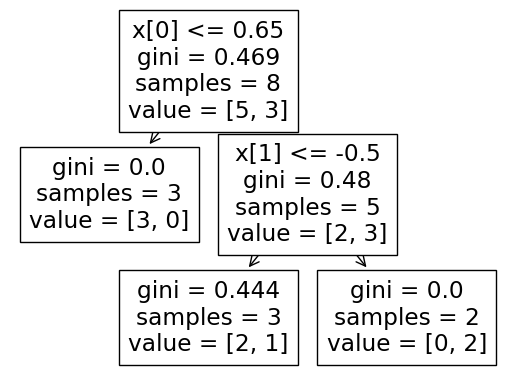

In [6]:
r = export_text(tree_clf)
plot_tree(tree_clf)
print(r)

# # Predicting classes and class probabilities
print(tree_clf.predict_proba([[5, 1.5]]))
print(tree_clf.predict([[5, 1.5]]))